# Explore anomaly scores

In [1]:
import os
# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import seaborn as sns

from anomaly.constants import GALAXY_LINES
from anomaly.utils import specobjid_to_idx
from anomaly.utils import VelocityFilter
from anomaly.utils import AnomalyOverlapAnalyzer
from autoencoders.ae import AutoEncoder

from sdss.metadata import MetaData

meta = MetaData()

# Constants

In [3]:
se_cols = [
    'mse',
    'mse_filter_250',
    # 'mse_filter_300',
    'mse_97',
    # 'mse_95',
    'mse_filter_250_97',
    # 'mse_filter_250_95',
    # 'mse_filter_300_97', 'mse_filter_300_95'
]

se_rank_cols = [
    f"rank_{col}" for col in se_cols
]

# ----------------------------------------------
rse_cols = [
    f"{col}_rel" for col in se_cols
]

rse_rank_cols = [
    f"rank_{col}_rel" for col in se_cols
]
# ----------------------------------------------
se_family = [
    'mse',
    'mse_97',
    # 'mse_95',
    'mse_filter_250',
    # 'mse_filter_300',
    'mse_filter_250_97',
    # 'mse_filter_250_95',
    # 'mse_filter_300_97', 'mse_filter_300_95'
]

rse_family = [
    f'{col}_rel' for col in se_family
]

# Custom functions

## Scores arr to df

In [4]:
def scores_arr_to_df(score_paths, bin_idx_to_specobjid):

    score_names = [score.split("/")[-1][:-4] for score in score_paths]
    objids_bin = bin_idx_to_specobjid[:, 1]

    scores_dict = {}

    for score_name, score_path in zip(score_names, score_paths):

        print(f"Loading score: {score_name}")

        scores_dict[score_name] = np.load(score_path)[:, 0]

    scores_df = pd.DataFrame(data=scores_dict, index=objids_bin)
    scores_df.index.name = 'specobjid'

    return scores_df


## Residuals

In [5]:
def squared_residual(spec, spec_rec):

    flux_diff = np.abs(spec - spec_rec)
    
    return flux_diff**2

## Score name map

In [6]:
def map_score_name(score):
    """Maps score code names to more readable names."""
    if score == 'mse':
        return 'SE'
    elif score == 'mse_filter_250':
        return 'Filtered SE'
    elif score == 'mse_97':
        return 'Trimmed SE'
    elif score == 'mse_filter_250_97':
        return 'Filtered + Trimmed SE'
    
    elif score == 'mse_rel':
        return 'RSE'
    elif score == 'mse_filter_250_rel':
        return 'Filtered RSE'
    elif score == 'mse_97_rel':
        return 'Trimmed RSE'
    elif score == 'mse_filter_250_97_rel':
        return 'Filtered + Trimmed RSE'
    else:
        return score

## Score dist

In [7]:
def plot_hist_scores(
    df,
    score_family,
    x_label,
    bins=100,
    y_lim=(None, None),
    figsize=(20, 7)
):
    """
    Generates a 2x2 grid of histograms for a given list of 4
    scores against a metadata column.
    """
    fig, axs = plt.subplots(
        2, 2,
        sharex=True,
        figsize=figsize
    )
    
    axs = axs.flatten()

    for i, score in enumerate(score_family):
        # Create the hexbin plot
        _ = axs[i].hist(
            df[score], 
            bins=bins,
            color='tab:blue', edgecolor='black',
            linewidth=0.5
        )
        axs[i].set_yscale('log')
        axs[i].set_ylim(y_lim)
        # Formatting
        axs[i].minorticks_on()

        score_mapped = map_score_name(score)
        axs[i].text(
            0.5, 0.95,
            score_mapped,
            horizontalalignment="center", verticalalignment="center",
            transform=axs[i].transAxes,
            fontsize=12
        )

        if i == 2 or i == 3:
            axs[i].set_xlabel(x_label, fontsize=12)

    return fig, axs

## score Vs z \& S/N

In [8]:
def plot_hist_score_z_snr(
    df,
    score_family,
    x_col, x_label,
    gridsize=100,
    figsize=(20, 7)
):
    """
    Generates a 2x2 grid of hexbin plots for a given list of 4
    scores against a metadata column.
    """
    fig, axs = plt.subplots(
        2, 2,
        sharex=True,
        figsize=figsize
    )
    
    axs = axs.flatten()

    for i, score in enumerate(score_family):
        # Create the hexbin plot
        hb = axs[i].hexbin(
            df[x_col], 
            df[score], 
            gridsize=gridsize, 
            cmap='viridis',
            mincnt=1, 
            bins='log'
        )
        
        # Formatting
        axs[i].minorticks_on()
        score_mapped = map_score_name(score)            
        axs[i].set_title(score_mapped, fontsize=12)

        if i == 2 or i == 3:
            axs[i].set_xlabel(x_label, fontsize=12)
        
        # Add colorbar
        cb = fig.colorbar(hb, ax=axs[i])
        if i == 1 or i == 3:
            cb.set_label('Count')

    return fig, axs

# Config

## Directories

In [9]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
bin_id = 'bin_03'
#
ch_4_dir = f"{thesis_dir}/chapters/04_figures"
os.makedirs(f"{ch_4_dir}/{bin_id}", exist_ok=True)

## Data

In [10]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave*0.1
n_wave = wave.shape

spectra = np.load(
    f"{spectra_dir}/spectra_imputed.npy",
    mmap_mode="r"
)

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(
    f"{spectra_dir}/ids_imputing.npy",
    mmap_mode='r'
)


## Model

In [11]:
ae_model = AutoEncoder(
    reload=True,
    reload_from=f"{models_dir}/{bin_id}/winner",
)

## Scores

In [15]:
# # ```python

# score_paths = glob.glob(f"{scores_dir}/{bin_id}/*.npy")

# bin_idx_to_specobjid = np.load(
#     f"{spectra_dir}/"
#     f"{bin_id}/{bin_id}_index_specobjid.npy"
# )

# scores_df = scores_arr_to_df(score_paths, bin_idx_to_specobjid)
# scores_df.to_csv(
#     f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
#     index=True
# )
# # ```

In [12]:
score_df = pd.read_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    index_col='specobjid'
)

rank = np.arange(score_df.shape[0]) + 1
score_rank_df = score_df.copy()
# score_rank_df
for col in score_df.columns:

    index_sorted = score_df.sort_values(
        by=col, ascending=False
    ).index

    score_rank_df.loc[index_sorted, f'rank_{col}'] = rank
    score_rank_df[f'rank_{col}'].astype(int)

In [13]:
score_rank_df[['rank_mse', 'mse']].sort_values(by='mse', ascending=True).head(5)

,rank_mse,mse
specobjid,,
443765948722210816,181850.0,0.713246
2568244270221780992,181849.0,0.775097
502298449991985152,181848.0,0.791571
661020102417737728,181847.0,0.794226
2446716352250013696,181846.0,0.804526


In [14]:
artifact_id = 637325355518027776
score_rank_df.loc[artifact_id, se_cols + rse_cols]

mse                      10.488524
mse_filter_250           10.313478
mse_97                    5.903055
mse_filter_250_97         5.784308
mse_rel                  10.231443
mse_filter_250_rel        9.993050
mse_97_rel                6.219198
mse_filter_250_97_rel     6.094217
Name: 637325355518027776, dtype: float64

In [15]:
artifact_id = 637325355518027776
score_rank_df.loc[artifact_id, se_rank_cols + rse_rank_cols]

rank_mse                      190.0
rank_mse_filter_250            86.0
rank_mse_97                    27.0
rank_mse_filter_250_97         21.0
rank_mse_rel                   56.0
rank_mse_filter_250_rel        15.0
rank_mse_97_rel                20.0
rank_mse_filter_250_97_rel     18.0
Name: 637325355518027776, dtype: float64

In [16]:
n_spec = score_df.shape[0]
n_tops = [int(n_spec*p) for p in [0.001, 0.005, 0.01, 0.05]]
n_tops_perc = [f'{n/n_spec*100:.2f}%' for n in n_tops]

In [17]:
n_tops, n_tops_perc

([181, 909, 1818, 9092], ['0.10%', '0.50%', '1.00%', '5.00%'])

# Good and bad rec

## Data

In [18]:
rec_good_bad_dict = {
    'good': 443765948722210816,
    'bad': 531492683672217600
}

bad_id = rec_good_bad_dict["bad"]
idx_bad = specobjid_to_idx(bad_id, idx_id_spec)
bad_spec = spectra[idx_bad]
rec_bad_spec = ae_model.reconstruct(bad_spec)[0]
residual_bad = squared_residual(bad_spec, rec_bad_spec)
# -----------------------------------------
good_id = rec_good_bad_dict["good"]
idx_good = specobjid_to_idx(good_id, idx_id_spec)
good_spec = spectra[idx_good]
rec_good_spec = ae_model.reconstruct(good_spec)[0]
residual_good = squared_residual(good_spec, rec_good_spec)

## Figure

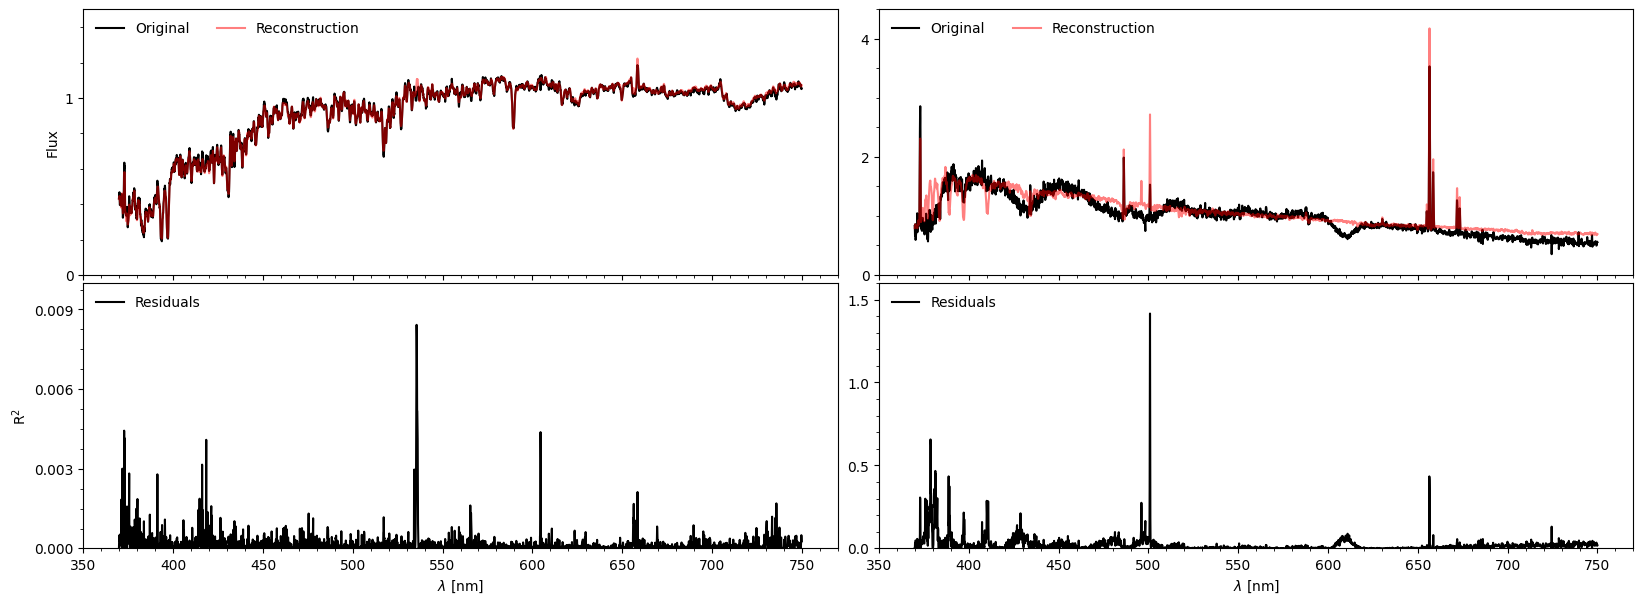

In [32]:
fig, axs = plt.subplots(
    2, 2,
    sharex=True,
    figsize=(20, 7)
)
alpha = 0.5
# ----------------------------------------------------
# Normal
axs[0, 0].plot(
    wave_nm, good_spec,
    color="black", label="Original"
)

axs[0, 0].plot(
    wave_nm, rec_good_spec,
    alpha=alpha,
    color="red", label="Reconstruction"
)

flux_ticks = [0, 1]
axs[0, 0].set_yticks(flux_ticks)
axs[0, 0].set_ylim(0, 1.5)

# ----------------------------------------------------
# Anomaly
axs[0, 1].plot(
    wave_nm, bad_spec,
    color="black", label="Original"
)
axs[0, 1].plot(
    wave_nm, rec_bad_spec,
    color="red", alpha=alpha, label="Reconstruction"
)

flux_ticks = [0, 2, 4]
axs[0, 1].set_yticks(flux_ticks)
axs[0, 1].set_ylim(0, 4.5)
# ----------------------------------------------------
# Residulas
# Normal
axs[1, 0].plot(
    wave_nm, residual_good,
    color="black", label="Residuals"
)

res_ticks = [0, 0.003, 0.006, 0.009]
axs[1, 0].set_yticks(res_ticks)
axs[1, 0].set_ylim(0, 0.01)

# Anomaly
axs[1, 1].plot(
    wave_nm, residual_bad,
    color="black", label="Residuals"
)
res_ticks = [0, 0.5, 1, 1.5]
axs[1, 1].set_yticks(res_ticks)
axs[1, 1].set_ylim(0, 1.6)

# ----------------------------------------------------
# labels
axs[0, 0].legend(
    loc='upper left',
    frameon=False,
    # fontsize=10,
    ncol=2
)
axs[0, 1].legend(
    loc='upper left',
    frameon=False,
    # fontsize=10,
    ncol=2
)
axs[1, 0].legend(loc='upper left', frameon=False)
axs[1, 1].legend(loc='upper left', frameon=False)

# ----------------------------------------------------

# wavelengt setup
axs[1, 0].set_xlim(350, 770)
axs[1, 1].set_xlim(350, 770)
# # wave_ticks = [370]
wave_ticks = list(np.arange(350, 751, 50))
axs[1, 0].set_xticks(wave_ticks)
axs[1, 1].set_xticks(wave_ticks)
# set minor ticks on
for ax in axs.flatten(): ax.minorticks_on()
# axe labels
# x
axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[1, 1].set_xlabel(r"$\lambda$ [nm]")
# y
axs[0, 0].set_ylabel("Flux")
axs[1, 0].set_ylabel(r"R$^2$")

# adjust vertical space
plt.subplots_adjust(
    hspace=0.03, 
    wspace=0.055
)

fig.savefig(
    f"{ch_4_dir}/{bin_id}/good_poor_rec_{bin_id}.pdf",
    bbox_inches='tight'
)

# SE illustrations

## SE Data 

In [19]:
mse_strong_artifact = {
    'strong':734111514142730240,
    'artifact': 378399434137954304
}

strong_id = mse_strong_artifact["strong"]
idx_strong = specobjid_to_idx(strong_id, idx_id_spec)
strong_spec = spectra[idx_strong]
rec_strong_spec = ae_model.reconstruct(strong_spec)[0]
residual_strong = squared_residual(strong_spec, rec_strong_spec)
# -----------------------------------------
artifact_id = mse_strong_artifact["artifact"]
idx_artifact = specobjid_to_idx(artifact_id, idx_id_spec)
artifact_spec = spectra[idx_artifact]
rec_artifact_spec = ae_model.reconstruct(artifact_spec)[0]
residual_artifact = squared_residual(artifact_spec, rec_artifact_spec)
# ----------------------------------------------------
# MSE anomaly score
mse_strong = score_df.loc[strong_id, 'mse']
mse_artifact = score_df.loc[artifact_id, 'mse']
mse_strong, mse_artifact

(31.56080803831112, 45.94360436290258)

In [20]:
n_wave = wave.shape
np.sqrt(np.sum(residual_artifact))

45.942413

## SE Figure

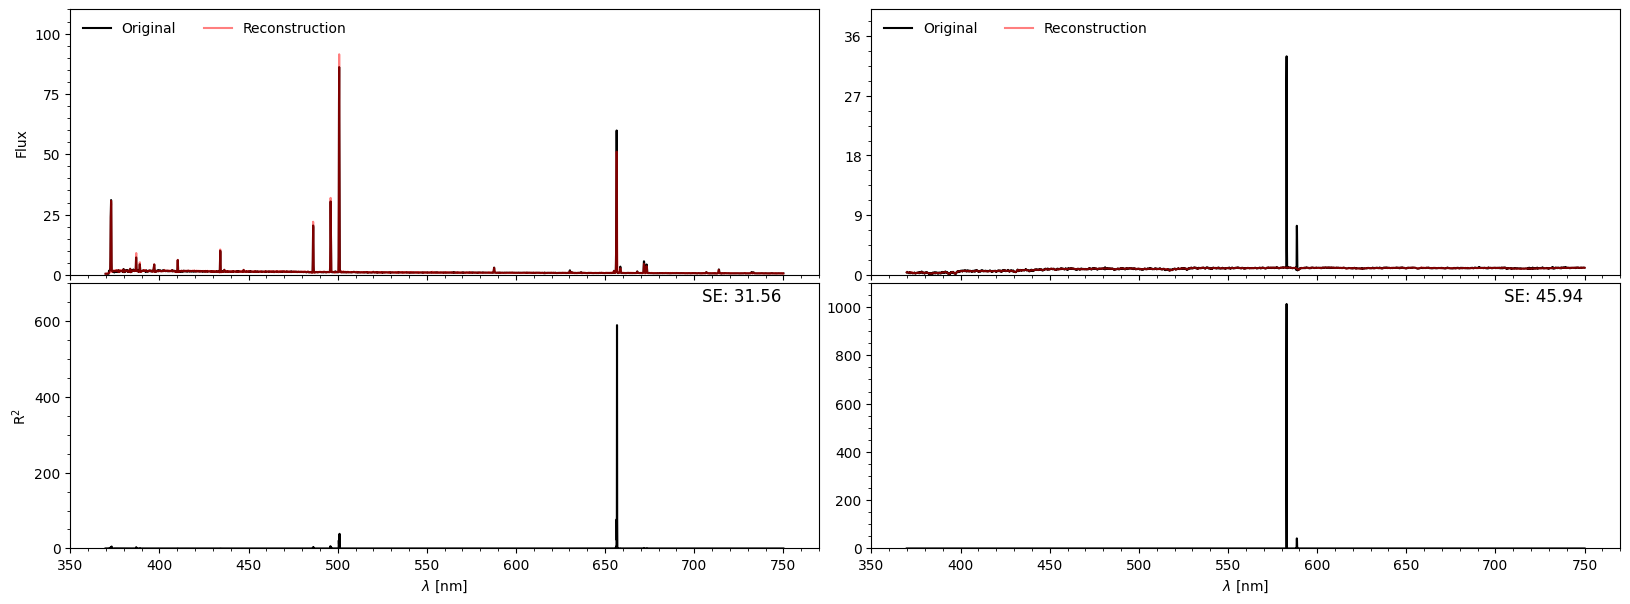

In [34]:
fig, axs = plt.subplots(
    2, 2,
    sharex=True,
    figsize=(20, 7)
)
alpha = 0.5
# ----------------------------------------------------
# Strong
axs[0, 0].plot(
    wave_nm, strong_spec,
    color="black", label="Original"
)

axs[0, 0].plot(
    wave_nm, rec_strong_spec,
    alpha=alpha,
    color="red", label="Reconstruction"
)

flux_ticks = [0, 25, 50, 75, 100]
axs[0, 0].set_yticks(flux_ticks)
axs[0, 0].set_ylim(0, 110)

# ----------------------------------------------------
# Artifact
axs[0, 1].plot(
    wave_nm, artifact_spec,
    color="black", label="Original"
)
axs[0, 1].plot(
    wave_nm, rec_artifact_spec,
    color="red", alpha=alpha, label="Reconstruction"
)

flux_ticks = [0, 9, 18, 27, 36]
axs[0, 1].set_yticks(flux_ticks)
axs[0, 1].set_ylim(0, 40)
# ----------------------------------------------------
# Residulas
# Strong
axs[1, 0].plot(
    wave_nm, residual_strong,
    color="black", label="Residuals"
)
res_ticks = [0, 200, 400, 600]
axs[1, 0].set_yticks(res_ticks)
axs[1, 0].set_ylim(0, 700)

axs[1, 0].text(
    0.95, 0.95,
    f"SE: {mse_strong:.2f}",
    horizontalalignment="right", verticalalignment="center",
    transform=axs[1, 0].transAxes,
    fontsize=12
)

# Artifact
axs[1, 1].plot(
    wave_nm, residual_artifact,
    color="black", label="Residuals"
)

res_ticks = [0, 200, 400, 600, 800, 1000]
axs[1, 1].set_yticks(res_ticks)
axs[1, 1].set_ylim(0, 1100)

axs[1, 1].text(
    0.95, 0.95,
    f"SE: {mse_artifact:.2f}",
    horizontalalignment="right", verticalalignment="center",
    transform=axs[1, 1].transAxes,
    fontsize=12
)
# ----------------------------------------------------
# labels
axs[0, 0].legend(
    loc='upper left',
    frameon=False,
    # fontsize=10,
    ncol=2
)
axs[0, 1].legend(
    loc='upper left',
    frameon=False,
    # fontsize=10,
    ncol=2
)

# ----------------------------------------------------

# wavelengt setup
axs[1, 0].set_xlim(350, 770)
axs[1, 1].set_xlim(350, 770)
# # wave_ticks = [370]
wave_ticks = list(np.arange(350, 751, 50))
axs[1, 0].set_xticks(wave_ticks)
axs[1, 1].set_xticks(wave_ticks)
# set minor ticks on
for ax in axs.flatten(): ax.minorticks_on()

# ax labels
axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[1, 1].set_xlabel(r"$\lambda$ [nm]")
axs[0, 0].set_ylabel("Flux")
axs[1, 0].set_ylabel(r"R$^2$")

# adjust vertical space
plt.subplots_adjust(
    hspace=0.03, 
    wspace=0.07
)

fig.savefig(
    f"{ch_4_dir}/{bin_id}/se_res_strong_artifact_{bin_id}.pdf",
    bbox_inches='tight'
)

## Filter SE Data

In [21]:
broad_specobjid = 1924292192684238848
idx_broad = specobjid_to_idx(broad_specobjid, idx_id_spec)
spec_broad = spectra[idx_broad]
spec_broad_rec = ae_model.reconstruct(spec_broad).reshape(-1)
residual_broad = squared_residual(spec_broad, spec_broad_rec)
# -------------------------------------------------------
# score and rank
mse_broad = score_df.loc[broad_specobjid, 'mse']
mse_broad_rank = score_rank_df.loc[broad_specobjid, 'rank_mse']
filtered_250_mse_broad = score_df.loc[broad_specobjid, 'mse_filter_250']
filtered_250_mse_broad_rank = score_rank_df.loc[broad_specobjid, 'rank_mse_filter_250']
filtered_300_mse_broad = score_df.loc[broad_specobjid, 'mse_filter_300']
filtered_300_mse_broad_rank = score_rank_df.loc[broad_specobjid, 'rank_mse_filter_300']

In [22]:
blue_specobjid = 3240361172402202624
idx_blue = specobjid_to_idx(blue_specobjid, idx_id_spec)
spec_blue = spectra[idx_blue]
spec_blue_rec = ae_model.reconstruct(spec_blue).reshape(-1)
residual_blue = squared_residual(spec_blue, spec_blue_rec)
# -------------------------------------------------------
# score and rank
mse_blue = score_df.loc[blue_specobjid, 'mse']
mse_blue_rank = score_rank_df.loc[blue_specobjid, 'rank_mse']
filtered_250_mse_blue = score_df.loc[blue_specobjid, 'mse_filter_250']
filtered_250_mse_blue_rank = score_rank_df.loc[blue_specobjid, 'rank_mse_filter_250']

In [23]:
emission_lines = list(GALAXY_LINES.keys())

velocity_fil_fn = VelocityFilter(
    wave=wave, velocity_filter=250,
    lines=emission_lines
)

vel_mask = velocity_fil_fn.get_velocity_filter_mask()

## Filter SE figure

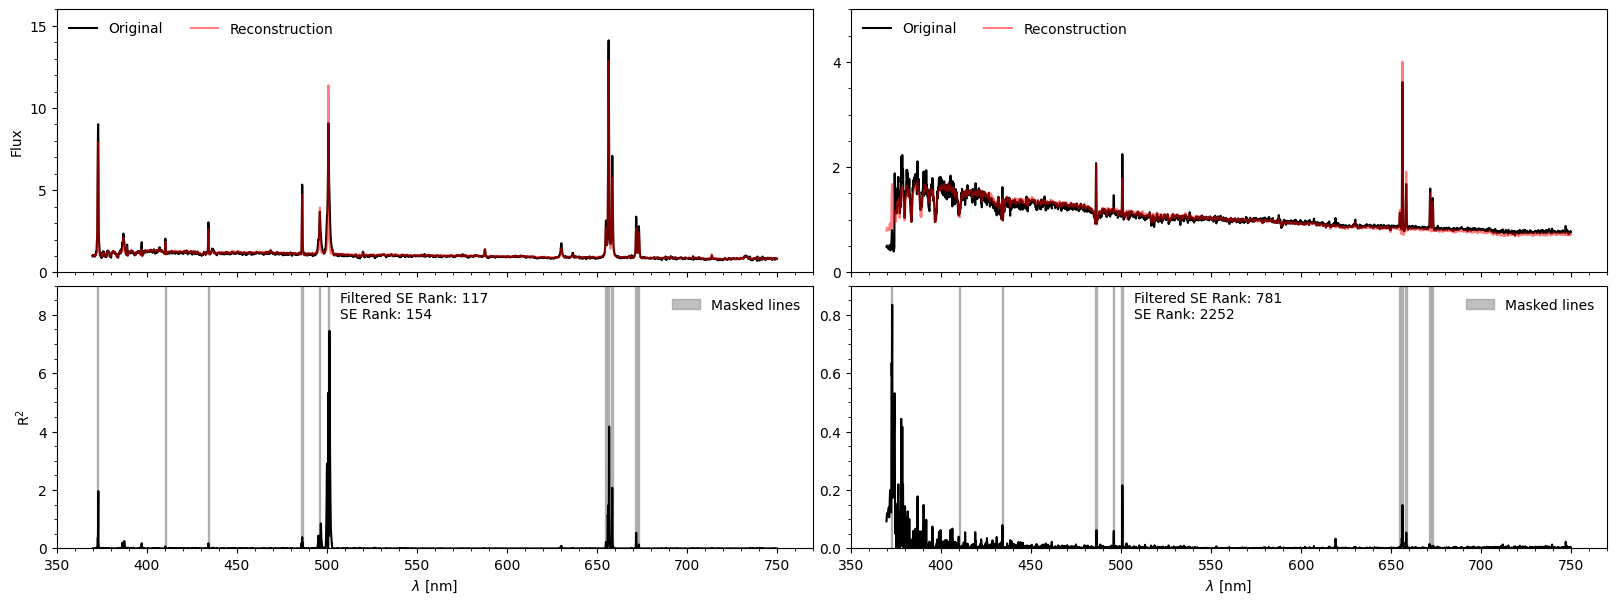

In [25]:
fig, axs = plt.subplots(
    2, 2,
    sharex=True,
    figsize=(20, 7)
)
# ----------------------------------------------------
# broad
axs[0, 0].plot(wave_nm, spec_broad, color='black', alpha=1, label='Original')
axs[0, 0].plot(wave_nm, spec_broad_rec, color='red', alpha=0.5, label='Reconstruction')

flux_ticks = [0, 5, 10, 15]
axs[0, 0].set_yticks(flux_ticks)
axs[0, 0].set_ylim(0, 16)
# ----------------------------------------------------
# residual
axs[1, 0].plot(wave_nm, residual_broad, color='black')
res_ticks = [0, 2, 4, 6, 8]
axs[1, 0].set_yticks(res_ticks)
axs[1, 0].set_ylim(0, 9)
# squared error  and rank
axs[1, 0].text(
    0.375, 0.92,
    f"Filtered SE Rank: {filtered_250_mse_broad_rank:.0f}\n"
    f"SE Rank: {mse_broad_rank:.0f}",
    # f"Filtered SE: {filtered_250_mse_broad:.2f} "
    # f"(Rank: {filtered_250_mse_broad_rank:.0f})\n"
    # f"SE: {mse_broad:.2f} "
    # f"(Rank: {mse_broad_rank:.0f})",
    horizontalalignment="left", verticalalignment="center",
    transform=axs[1, 0].transAxes,
    fontsize=10
)
# ----------------------------------------------------
# blue
axs[0, 1].plot(wave_nm, spec_blue, color='black', alpha=1, label='Original')
axs[0, 1].plot(wave_nm, spec_blue_rec, color='red', alpha=0.5, label='Reconstruction')

flux_ticks = [0, 2, 4]
axs[0, 1].set_yticks(flux_ticks)
axs[0, 1].set_ylim(0, 5)
# ----------------------------------------------------
# residual
axs[1, 1].plot(wave_nm, residual_blue, color='black')

res_ticks = [0, 0.2, 0.4, 0.6, 0.8]
axs[1, 1].set_yticks(res_ticks)
axs[1, 1].set_ylim(0, 0.9)
# squared error  and rank
axs[1, 1].text(
    0.375, 0.92,
    f"Filtered SE Rank: {filtered_250_mse_blue_rank:.0f}\n"
    f"SE Rank: {mse_blue_rank:.0f}",
    # f"Filtered SE: {filtered_250_mse_blue:.2f} "
    # f"(Rank: {filtered_250_mse_blue_rank:.0f})\n"
    # f"SE: {mse_blue:.2f} "
    # f"(Rank: {mse_blue_rank:.0f})",
    horizontalalignment="left", verticalalignment="center",
    transform=axs[1, 1].transAxes,
    fontsize=10
)
# ----------------------------------------------------
# shaded regions
axs[1, 0].fill_between(
    wave_nm, 
    0, 1,              # Fill from bottom (0) to top (1) of the axis
    where=~vel_mask,    # Only where your mask is True
    color='gray',      # Color of the shade
    alpha=0.5,         # Transparency
    transform=axs[1, 0].get_xaxis_transform(), # Key: maps y to axis fractions
    label='Masked lines'
)
axs[1, 1].fill_between(
    wave_nm, 
    0, 1,              # Fill from bottom (0) to top (1) of the axis
    where=~vel_mask,    # Only where your mask is True
    color='gray',      # Color of the shade
    alpha=0.5,         # Transparency
    transform=axs[1, 1].get_xaxis_transform(), # Key: maps y to axis fractions
    label='Masked lines'
)

# ----------------------------------------------------
# labels
axs[0, 0].legend(
    loc='upper left',
    frameon=False,
    # fontsize=10,
    ncol=2
)
axs[0, 1].legend(
    loc='upper left',
    frameon=False,
    # fontsize=10,
    ncol=2
)
# # leggends
axs[1, 0].legend(loc='upper right', frameon=False, fontsize=10)
axs[1, 1].legend(loc='upper right', frameon=False, fontsize=10)
# for ax in axs.flatten():
#     ax.legend(loc='upper right', frameon=False, fontsize=10)
# ---------------------------------------------------- 
# wavelengt setup
axs[1, 1].set_xlim(350, 770)
axs[0, 1].set_xlim(350, 770)
# # wave_ticks = [370]
wave_ticks = list(np.arange(350, 751, 50))
axs[1, 1].set_xticks(wave_ticks)
axs[0, 1].set_xticks(wave_ticks)
# set minor ticks on
for ax in axs.flatten(): ax.minorticks_on()
# ax labels
axs[1, 1].set_xlabel(r"$\lambda$ [nm]")
axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[0, 0].set_ylabel("Flux")
axs[1, 0].set_ylabel(r"R$^2$")

# adjust vertical space
plt.subplots_adjust(hspace=0.05, wspace=0.05)
# ---------------------------------------------------- 
fig.savefig(
    f"{ch_4_dir}/{bin_id}/filt_se_res_broad_{bin_id}.pdf",
    bbox_inches='tight'
)

## Trim SE data

In [26]:
score_rank_df.loc[broad_specobjid, ['rank_mse', 'rank_mse_filter_250', 'rank_mse_97']]

rank_mse               154.0
rank_mse_filter_250    117.0
rank_mse_97            721.0
Name: 1924292192684238848, dtype: float64

In [27]:
score_rank_df.loc[strong_id, ['rank_mse', 'rank_mse_filter_250', 'rank_mse_97']]

rank_mse                14.0
rank_mse_filter_250    128.0
rank_mse_97             63.0
Name: 734111514142730240, dtype: float64

In [28]:
score_rank_df.loc[artifact_id, ['rank_mse', 'rank_mse_filter_250', 'rank_mse_97']]

rank_mse                    3.0
rank_mse_filter_250         3.0
rank_mse_97            124420.0
Name: 378399434137954304, dtype: float64

In [29]:
score_rank_df.loc[artifact_id, ['mse', 'mse_filter_250', 'mse_97']]

mse               45.943604
mse_filter_250    45.940855
mse_97             1.719226
Name: 378399434137954304, dtype: float64

In [30]:
line_bumpy_id = 1530151624956209152
idx_line_bumpy = specobjid_to_idx(line_bumpy_id, idx_id_spec)
spec_line_bumpy = spectra[idx_line_bumpy]
spec_line_bumpy_rec = ae_model.reconstruct(spec_line_bumpy).reshape(-1)
residual_line_bumpy = squared_residual(spec_line_bumpy, spec_line_bumpy_rec)
threshold_line_bumpy = np.nanpercentile(residual_line_bumpy, 97)
# -------------------------------------------------------
# score and rank
mse_line_bumpy = score_df.loc[line_bumpy_id, 'mse']
mse_line_bumpy_rank = score_rank_df.loc[line_bumpy_id, 'rank_mse']
filtered_250_mse_line_bumpy = score_df.loc[line_bumpy_id, 'mse_filter_250']
filtered_250_mse_line_bumpy_rank = score_rank_df.loc[line_bumpy_id, 'rank_mse_filter_250']
mse_97_line_bumpy = score_df.loc[line_bumpy_id, 'mse_97']
mse_97_line_bumpy_rank = score_rank_df.loc[line_bumpy_id, 'rank_mse_97']

In [31]:
mse_line_bumpy, mse_line_bumpy_rank, \
filtered_250_mse_line_bumpy, filtered_250_mse_line_bumpy_rank, \
mse_97_line_bumpy, mse_97_line_bumpy_rank

(9.999728565588748, 209.0, 8.775757904262841, 123.0, 8.159979805365763, 7.0)

In [32]:
star_id = 2486065949363431424
idx_star = specobjid_to_idx(star_id, idx_id_spec)
spec_star = spectra[idx_star]
spec_star_rec = ae_model.reconstruct(spec_star).reshape(-1)
residual_star = squared_residual(spec_star, spec_star_rec)
threshold_star = np.nanpercentile(residual_star, 97)
# -------------------------------------------------------
# score and rank
mse_star = score_df.loc[star_id, 'mse']
mse_star_rank = score_rank_df.loc[star_id, 'rank_mse']
filtered_250_mse_star = score_df.loc[star_id, 'mse_filter_250']
filtered_250_mse_star_rank = score_rank_df.loc[star_id, 'rank_mse_filter_250']
mse_97_star = score_df.loc[star_id, 'mse_97']
mse_97_star_rank = score_rank_df.loc[star_id, 'rank_mse_97']

In [33]:
residual_line_bumpy.max()

6.021895

## Trim SE figure

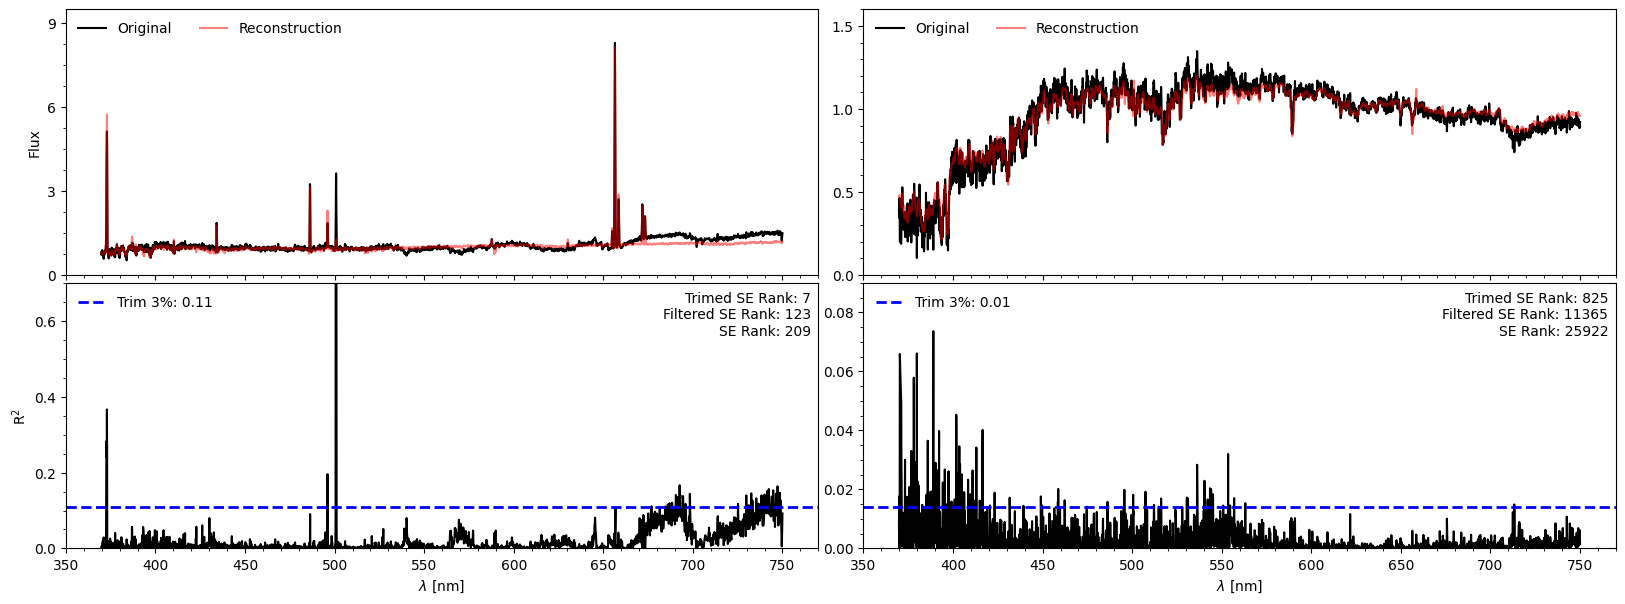

In [34]:
fig, axs = plt.subplots(
    2, 2,
    sharex=True,
    figsize=(20, 7)
)
alpha = 0.5
# ----------------------------------------------------
# Line bumpy
axs[0, 0].plot(
    wave_nm, spec_line_bumpy,
    color="black", label="Original"
)

axs[0, 0].plot(
    wave_nm, spec_line_bumpy_rec,
    alpha=alpha,
    color="red", label="Reconstruction"
)

flux_ticks = [0, 3, 6, 9]
axs[0, 0].set_yticks(flux_ticks)
axs[0, 0].set_ylim(0, 9.5)

# ----------------------------------------------------
# star
axs[0, 1].plot(
    wave_nm, spec_star,
    color="black", label="Original"
)
axs[0, 1].plot(
    wave_nm, spec_star_rec,
    color="red", alpha=alpha, label="Reconstruction"
)

flux_ticks = [0, 0.5, 1, 1.5]
axs[0, 1].set_yticks(flux_ticks)
axs[0, 1].set_ylim(0, 1.6)
# ----------------------------------------------------
# Residulas
# line bumpy
axs[1, 0].plot(
    wave_nm, residual_line_bumpy,
    color="black", #label="Residuals"
)
res_ticks = [0, 0.2, 0.4, 0.6]
axs[1, 0].set_yticks(res_ticks)
axs[1, 0].set_ylim(0, 0.7)

# star
axs[1, 1].plot(
    wave_nm, residual_star,
    color="black", #label="Residuals"
)

res_ticks = [0, 0.02, 0.04, 0.06, 0.08]
axs[1, 1].set_yticks(res_ticks)
axs[1, 1].set_ylim(0, 0.09)

# ----------------------------------------------------
# Sqared error  and rank
axs[1, 0].text(
    0.99, 0.88,
    f"Trimed SE Rank: {mse_97_line_bumpy_rank:.0f}\n"
    f"Filtered SE Rank: {filtered_250_mse_line_bumpy_rank:.0f}\n"
    f"SE Rank: {mse_line_bumpy_rank:.0f}",
    # f"Trimed SE: {mse_97_line_bumpy:.2f} "
    # f"(Rank: {mse_97_line_bumpy_rank:.0f})\n"
    # f"Filtered SE: {filtered_250_mse_line_bumpy:.2f} "
    # f"(Rank: {filtered_250_mse_line_bumpy_rank:.0f})\n"
    # f"SE: {mse_line_bumpy:.2f} "
    # f"(Rank: {mse_line_bumpy_rank:.0f})",
    horizontalalignment="right", verticalalignment="center",
    transform=axs[1,0].transAxes,
    fontsize=10
)

axs[1, 1].text(
    0.99, 0.88,
    f"Trimed SE Rank: {mse_97_star_rank:.0f}\n"
    f"Filtered SE Rank: {filtered_250_mse_star_rank:.0f}\n"
    f"SE Rank: {mse_star_rank:.0f}",
    # f"Trimed SE: {mse_97_star:.2f} "
    # f"(Rank: {mse_97_star_rank:.0f})\n"
    # f"Filtered SE: {filtered_250_mse_star:.2f} "
    # f"(Rank: {filtered_250_mse_star_rank:.0f})\n"
    # f"SE: {mse_star:.2f} "
    # f"(Rank: {mse_star_rank:.0f})",
    horizontalalignment="right", verticalalignment="center",
    transform=axs[1,1].transAxes,
    fontsize=10
)
# ----------------------------------------------------
# threshold lines
axs[1, 0].axhline(
    y=threshold_line_bumpy, 
    color='blue', 
    linestyle='--', 
    linewidth=2,
    label=f'Trim 3%: {threshold_line_bumpy:.2f}'
)
axs[1, 1].axhline(
    y=threshold_star, 
    color='blue', 
    linestyle='--', 
    linewidth=2,
    label=f'Trim 3%: {threshold_star:.2f}'
)
# ----------------------------------------------------
# labels
axs[0, 0].legend(
    loc='upper left',
    frameon=False,
    # fontsize=10,
    ncol=2
)
axs[0, 1].legend(
    loc='upper left',
    frameon=False,
    # fontsize=10,
    ncol=2
)
axs[1, 0].legend(loc='upper left', frameon=False)
axs[1, 1].legend(loc='upper left', frameon=False)
# ----------------------------------------------------

# wavelengt setup
axs[1, 0].set_xlim(350, 770)
axs[1, 1].set_xlim(350, 770)
# # wave_ticks = [370]
wave_ticks = list(np.arange(350, 751, 50))
axs[1, 0].set_xticks(wave_ticks)
axs[1, 1].set_xticks(wave_ticks)
# set minor ticks on
for ax in axs.flatten(): ax.minorticks_on()

# ax labels
axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[1, 1].set_xlabel(r"$\lambda$ [nm]")
axs[0, 0].set_ylabel("Flux")
axs[1, 0].set_ylabel(r"R$^2$")

# adjust vertical space
plt.subplots_adjust(
    hspace=0.03,
    wspace=0.06
)

fig.savefig(
    f"{ch_4_dir}/{bin_id}/se_97_res_line_bumpy_star_{bin_id}.pdf",
    bbox_inches='tight'
)

## Filtered + Trim data

## Filteder + Trim Fig

# Ranks of Specs in figures

In [ ]:
mse_strong_artifact = {
    'strong':734111514142730240,
    'artifact': 378399434137954304
}
strong_id = mse_strong_artifact["strong"]
artifact_id = mse_strong_artifact["artifact"]

filtered_broad_blue = {
    'broad':1924292192684238848,
    'blue': 3240361172402202624
}
broad_id = filtered_broad_blue["broad"]
blue_id = filtered_broad_blue["blue"]

trimmed_bumpy_star = {
    'bumpy':1530151624956209152,
    'star': 2486065949363431424
}

bumpy_id = trimmed_bumpy_star["bumpy"]
star_id = trimmed_bumpy_star["star"]

In [ ]:
score_rank_df.loc[
    [strong_id, artifact_id, broad_id, blue_id, bumpy_id, star_id],
    ['rank_mse', 'rank_mse_filter_250', 'rank_mse_97', 'rank_mse_filter_250_97']
]

In [ ]:
score_rank_df.loc[
    [strong_id, artifact_id, broad_id, blue_id, bumpy_id, star_id],
    ['mse', 'mse_filter_250', 'mse_97', 'mse_filter_250_97']
]

# Histograms Scores

## Data prep

In [16]:
score_cols = se_cols + rse_cols
rank_cols = se_rank_cols + rse_rank_cols

score_norm_meta_df = score_rank_df[score_cols + rank_cols].join(
    final_meta_df[['z', 'snMedian']],
    how='inner'
).copy()

score_norm_meta_df[score_cols] = score_norm_meta_df[
    score_cols
] / score_norm_meta_df[score_cols].max()

In [ ]:
bad_specobjid = 531492683672217600
broad_specobjid = 1924292192684238848
score_norm_meta_df.loc[[bad_specobjid, broad_specobjid], rank_cols]

## Score descriptive stats

In [ ]:
score_norm_meta_df[score_cols].describe(
    percentiles=np.linspace(0.1, 0.9, 9)
)

## Top 1% score thresholds

In [ ]:
top_1_thresholds = score_norm_meta_df[score_cols].quantile(0.99)
print("Score thresholds for the Top 1% of anomalies:")
print("-" * 40)
print(top_1_thresholds)

## SE family dist

In [ ]:
fig, axs = plot_hist_scores(
    score_norm_meta_df,
    se_family,
    x_label='Normalized score',
    bins=50,
    y_lim=(None, 0.25e6)
)

for i, score in enumerate(se_family):

    axs[i].axvline(
        x=top_1_thresholds[score],
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Top 1% >= {top_1_thresholds[score]:.4f} '
    )
    axs[i].legend(frameon=False, loc='upper right')

axs[0].set_ylabel('Count', fontsize=12)
axs[2].set_ylabel('Count', fontsize=12)

plt.subplots_adjust(
    hspace=0.05,
    wspace=0.06
)
# save figure
fig.savefig(
    f"{ch_4_dir}/{bin_id}/hist_ses_{bin_id}.pdf",
    bbox_inches='tight'
)

## RSE family dist

In [ ]:
fig, axs = plot_hist_scores(
    score_norm_meta_df,
    rse_family,
    x_label='Normalized score',
    bins=50,
    y_lim=(None, 0.25e6)
)

for i, score in enumerate(rse_family):

    axs[i].axvline(
        x=top_1_thresholds[score],
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Top 1% >= {top_1_thresholds[score]:.4f} '
    )
    axs[i].legend(frameon=False)

axs[0].set_ylabel('Count', fontsize=12)
axs[2].set_ylabel('Count', fontsize=12)

plt.subplots_adjust(
    hspace=0.05,
    wspace=0.06
)

# save figure
fig.savefig(
    f"{ch_4_dir}/{bin_id}/hist_rses_{bin_id}.pdf",
    bbox_inches='tight'
)

# Metadata histograms

## Redshift

In [ ]:
z_quantile = 95
top_z_threshold = score_norm_meta_df['z'].quantile(z_quantile/100)
print(f"z quantile: {z_quantile}%:")
print("-" * 40)
print(top_z_threshold)

In [ ]:
fig, axs = plot_hist_score_z_snr(score_norm_meta_df, se_cols, 'z', 'z')

for i, score in enumerate(se_cols):

    axs[i].axhline(
        y=top_1_thresholds[score],
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Top 1% > {top_1_thresholds[score]:.4f} '
    )

    # axs[i].axvline(
    #     x=top_z_threshold,
    #     color='black',
    #     linestyle='--',
    #     linewidth=2,
    #     label=f'z={top_z_threshold:.2f}\n{z_quantile}th percentile'
    # )

    axs[i].legend(frameon=False, loc='upper right')

axs[0].set_ylabel('Score', fontsize=12)
axs[2].set_ylabel('Score', fontsize=12)

plt.subplots_adjust(
    hspace=0.15,
    wspace=0.005
)

# save figure
fig.savefig(
    f"{ch_4_dir}/{bin_id}/hexbin_se_z_{bin_id}.pdf",
    bbox_inches='tight'
)

In [ ]:
fig, axs = plot_hist_score_z_snr(score_norm_meta_df, rse_cols, 'z', 'z')

for i, score in enumerate(rse_cols):

    axs[i].axhline(
        y=top_1_thresholds[score],
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Top 1% >= {top_1_thresholds[score]:.4f} '
    )

    # axs[i].axvline(
    #     x=top_z_threshold,
    #     color='black',
    #     linestyle='--',
    #     linewidth=2,
    #     label=f'z={top_z_threshold:.2f}\n{z_quantile}th percentile'
    # )

    axs[i].legend(frameon=False, loc='upper right')

axs[0].set_ylabel('Score', fontsize=12)
axs[2].set_ylabel('Score', fontsize=12)

plt.subplots_adjust(
    hspace=0.15,
    wspace=0.005
)
# save figure
fig.savefig(
    f"{ch_4_dir}/{bin_id}/hexbin_rse_z_{bin_id}.pdf",
    bbox_inches='tight'
)

## S/N

### SE all S/N

In [ ]:
snr_quantile = 95
top_snr_threshold = score_norm_meta_df['snMedian'].quantile(snr_quantile/100)
print(f"S/N: {snr_quantile}%:")
print("-" * 40)
print(top_snr_threshold)
# ------------------------------
fig, axs = plot_hist_score_z_snr(score_norm_meta_df, se_cols, 'snMedian', 'median S/N')

for i, score in enumerate(se_cols):

    axs[i].axhline(
        y=top_1_thresholds[score],
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Top 1% >= {top_1_thresholds[score]:.4f} '
    )

    axs[i].axvline(
        x=top_snr_threshold,
        color='black',
        linestyle='--',
        linewidth=2,
        label=f'median S/N:{top_snr_threshold:.2f}\n{snr_quantile}th percentile'
    )

    axs[i].legend(frameon=False, loc='upper right')

axs[0].set_ylabel('Score', fontsize=12)
axs[2].set_ylabel('Score', fontsize=12)

x_ticks = [15, 30, 45, 60, 75, 90]
axs[0].set_xticks(x_ticks)
axs[2].set_xticks(x_ticks)

plt.subplots_adjust(
    hspace=0.15,
    wspace=0.005
)
# save figure
fig.savefig(
    f"{ch_4_dir}/{bin_id}/hexbin_se_snr_{bin_id}.pdf",
    bbox_inches='tight'
)

### SE S/N 50th

In [ ]:
snr_min = score_norm_meta_df['snMedian'].min()
snr_50 = score_norm_meta_df['snMedian'].quantile(0.5)

snr_mask = score_norm_meta_df['snMedian'] <= snr_50
snr_trim_df = score_norm_meta_df.loc[snr_mask]

fig, axs = plot_hist_score_z_snr(snr_trim_df, se_cols, 'snMedian', 'median S/N')

for i, score in enumerate(se_cols):

    axs[i].axhline(
        y=top_1_thresholds[score],
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Top 1% >= {top_1_thresholds[score]:.4f} '
    )

    # axs[i].axvline(
    #     x=top_snr_threshold,
    #     color='black',
    #     linestyle='--',
    #     linewidth=2,
    #     label=f'median S/N:{top_snr_threshold:.2f}\n{snr_quantile}th percentile'
    # )

    axs[i].legend(frameon=False, loc='upper right')


axs[0].set_ylabel('Score', fontsize=12)
axs[2].set_ylabel('Score', fontsize=12)

x_ticks = [18, 19, 20, 21, 22]
axs[0].set_xticks(x_ticks)
axs[2].set_xticks(x_ticks)

# x_lim = (17.4, 22.1)
# axs[0].set_xlim(x_lim)
# axs[2].set_xlim(x_lim)


plt.subplots_adjust(
    hspace=0.15,
    wspace=0.005
)
# save figure
fig.savefig(
    f"{ch_4_dir}/{bin_id}/hexbin_se_snr_leq_50_{bin_id}.pdf",
    bbox_inches='tight'
)

### RSE all S/N

In [ ]:
fig, axs = plot_hist_score_z_snr(score_norm_meta_df, rse_cols, 'snMedian', 'median S/N')

for i, score in enumerate(rse_cols):

    axs[i].axhline(
        y=top_1_thresholds[score],
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Top 1% >= {top_1_thresholds[score]:.4f} '
    )
    
    axs[i].axvline(
        x=top_snr_threshold,
        color='black',
        linestyle='--',
        linewidth=2,
        label=f'median S/N {snr_quantile}% quantile'
    )

    axs[i].legend(frameon=False, loc='upper right')

axs[0].set_ylabel('Score', fontsize=12)
axs[2].set_ylabel('Score', fontsize=12)

x_ticks = [15, 30, 45, 60, 75, 90]
axs[0].set_xticks(x_ticks)
axs[2].set_xticks(x_ticks)

plt.subplots_adjust(
    hspace=0.15,
    wspace=0.005
)

# save figure
fig.savefig(
    f"{ch_4_dir}/{bin_id}/hexbin_rse_snr_{bin_id}.pdf",
    bbox_inches='tight'
)

### RSE S/N 50th

In [ ]:
snr_min = score_norm_meta_df['snMedian'].min()
snr_50 = score_norm_meta_df['snMedian'].quantile(0.5)

snr_mask = score_norm_meta_df['snMedian'] <= snr_50
snr_trim_df = score_norm_meta_df.loc[snr_mask]

fig, axs = plot_hist_score_z_snr(snr_trim_df, rse_cols, 'snMedian', 'median S/N')

for i, score in enumerate(rse_cols):

    axs[i].axhline(
        y=top_1_thresholds[score],
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Top 1% >= {top_1_thresholds[score]:.4f} '
    )

    # axs[i].axvline(
    #     x=top_snr_threshold,
    #     color='black',
    #     linestyle='--',
    #     linewidth=2,
    #     label=f'median S/N:{top_snr_threshold:.2f}\n{snr_quantile}th percentile'
    # )

    axs[i].legend(frameon=False, loc='upper right')


axs[0].set_ylabel('Score', fontsize=12)
axs[2].set_ylabel('Score', fontsize=12)

x_ticks = [18, 19, 20, 21, 22]
axs[0].set_xticks(x_ticks)
axs[2].set_xticks(x_ticks)

# x_lim = (17.4, 22.1)
# axs[0].set_xlim(x_lim)
# axs[2].set_xlim(x_lim)


plt.subplots_adjust(
    hspace=0.15,
    wspace=0.005
)
# save figure
fig.savefig(
    f"{ch_4_dir}/{bin_id}/hexbin_rse_snr_leq_50_{bin_id}.pdf",
    bbox_inches='tight'
)

# Median Specs

In [ ]:
n_spec = score_norm_meta_df.shape[0]
n_tops = [int(n_spec*p) for p in [0.001, 0.005, 0.01, 0.05]]
n_tops_perc = [f'{n/n_spec*100:.2f}%' for n in n_tops]
n_tops, n_tops_perc

## SE family

In [ ]:
n_top_1_per_anomalies = int(n_spec*0.01)

specids_mse_top_1_dict = {}

for score in se_cols:

    specids_top_1 = score_norm_meta_df[score].sort_values(
        ascending=False
    ).index.to_numpy()[:n_top_1_per_anomalies]

    specids_mse_top_1_dict[score] = specids_top_1

In [ ]:
spec_idx_mse_top_1_dict = {}

for score in se_cols:
    
    spec_idx_list = []

    for objid in specids_mse_top_1_dict[score]:

        spec_idx = specobjid_to_idx(
            objid, idx_id_spec
        )

        spec_idx_list.append(spec_idx)
    
    spec_idx_mse_top_1_dict[score] = spec_idx_list

### Spec prep

In [ ]:
spec_mse = spectra[spec_idx_mse_top_1_dict['mse'], :]
spec_mse_median = np.nanmedian(spec_mse, axis=0)
spec_mse_mean = np.nanmean(spec_mse, axis=0)
# ------------------------------------------------------
spec_mse_filter = spectra[spec_idx_mse_top_1_dict['mse_filter_250'], :]
spec_mse_filter_median = np.nanmedian(spec_mse_filter, axis=0)
spec_mse_filter_mean = np.nanmean(spec_mse_filter, axis=0)
# ------------------------------------------------------
spec_trim = spectra[spec_idx_mse_top_1_dict['mse_97'], :]
spec_trim_median =  np.nanmedian(spec_trim, axis=0)
spec_trim_mean =  np.nanmean(spec_trim, axis=0)
# ------------------------------------------------------
spec_filter_trim = spectra[spec_idx_mse_top_1_dict['mse_filter_250_97'], :]
spec_filter_trim_median = np.nanmedian(spec_filter_trim, axis=0)
spec_filter_trim_mean = np.nanmean(spec_filter_trim, axis=0)


### Median spec

In [ ]:
fig, axs = plt.subplots(
    2, 2,
    sharex=True,
    figsize=(20, 9)
)

# ------------------------------------------------------
axs[0, 0].plot(wave_nm, spec_mse_median, color='black')
# ------------------------------------------------------
axs[0, 1].plot(wave_nm, spec_mse_filter_median, color='black')
# ------------------------------------------------------
axs[1, 0].plot(wave_nm, spec_trim_median, color='black')
# ------------------------------------------------------
axs[1, 1].plot(wave_nm, spec_filter_trim_median, color='black')
# ------------------------------------------------------
# wavelengt setup
axs[1, 0].set_xlim(350, 770)
axs[1, 1].set_xlim(350, 770)

wave_ticks = list(np.arange(350, 751, 50))
axs[1, 0].set_xticks(wave_ticks)
axs[1, 1].set_xticks(wave_ticks)

scores_names = ["SE", "Filtered SE", "Trimmed SE", "Filtered + Trimmed SE"]
# set minor ticks on
for ax, score in zip(axs.flatten(), scores_names):
    ax.minorticks_on()

    if score == "SE":
        y_ticks = [0, 3, 6, 9, 12]
        ax.set_ylim(0, 12.5)
    elif score == "Filtered SE":
        y_ticks = [0, 3, 6, 9]
        ax.set_ylim(0, 9.5)
    elif score == "Trimmed SE":
        y_ticks = [0, 3, 6, 9]
        ax.set_ylim(0, 10)
    else:  # Filtered + Trimmed RSE
        y_ticks = [0, 3, 6, 9]
        ax.set_ylim(0, 10)

    ax.set_yticks(y_ticks)

    ax.text(
        0.02, 0.95,
        f" Median spectrum of top 1% anomalies for {score} score",
        horizontalalignment="left", verticalalignment="center",
        transform=ax.transAxes,
        fontsize=12
    )

axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[1, 1].set_xlabel(r"$\lambda$ [nm]")
axs[0, 0].set_ylabel("Flux")
axs[1, 0].set_ylabel("Flux")

# adjust vertical space
plt.subplots_adjust(
    hspace=0.05,
    wspace=0.05
)

# save figure
fig.savefig(
    f"{ch_4_dir}/{bin_id}/median_spec_top_se_{bin_id}.pdf",
    bbox_inches='tight'
)

## RSE family

In [ ]:
n_top_1_per_anomalies = int(n_spec*0.01)

specids_rse_top_1_dict = {}

for score in rse_cols:

    specids_top_1 = score_norm_meta_df[score].sort_values(
        ascending=False
    ).index.to_numpy()[:n_top_1_per_anomalies]

    specids_rse_top_1_dict[score] = specids_top_1

In [ ]:
spec_idx_rse_top_1_dict = {}

for score in rse_cols:
    
    spec_idx_list = []

    for objid in specids_rse_top_1_dict[score]:

        spec_idx = specobjid_to_idx(
            objid, idx_id_spec
        )

        spec_idx_list.append(spec_idx)
    
    spec_idx_rse_top_1_dict[score] = spec_idx_list

### Spec prep

In [ ]:
spec_rse = spectra[spec_idx_rse_top_1_dict['mse_rel'], :]
spec_rse_median = np.nanmedian(spec_rse, axis=0)
spec_rse_mean = np.nanmean(spec_rse, axis=0)
# ------------------------------------------------------
spec_rse_filter = spectra[spec_idx_rse_top_1_dict['mse_filter_250_rel'], :]
spec_rse_filter_median = np.nanmedian(spec_rse_filter, axis=0)
spec_rse_filter_mean = np.nanmean(spec_rse_filter, axis=0)
# ------------------------------------------------------
spec_rse_trim = spectra[spec_idx_rse_top_1_dict['mse_97_rel'], :]
spec_rse_trim_median =  np.nanmedian(spec_rse_trim, axis=0)
spec_rse_trim_mean =  np.nanmean(spec_rse_trim, axis=0)
# ------------------------------------------------------
spec_rse_filter_trim = spectra[spec_idx_rse_top_1_dict['mse_filter_250_97_rel'], :]
spec_rse_filter_trim_median = np.nanmedian(spec_rse_filter_trim, axis=0)
spec_rse_filter_trim_mean = np.nanmean(spec_rse_filter_trim, axis=0)

### Plot median spec

In [ ]:
fig, axs = plt.subplots(
    2, 2,
    sharex=True,
    figsize=(20, 9)
)

# ------------------------------------------------------
axs[0, 0].plot(wave_nm, spec_rse_median, color='black')
# ------------------------------------------------------
axs[0, 1].plot(wave_nm, spec_rse_filter_median, color='black')
# ------------------------------------------------------
axs[1, 0].plot(wave_nm, spec_rse_trim_median, color='black')
# ------------------------------------------------------
axs[1, 1].plot(wave_nm, spec_rse_filter_trim_median, color='black')

# wavelengt setup
axs[1, 0].set_xlim(350, 770)
axs[1, 1].set_xlim(350, 770)

wave_ticks = list(np.arange(350, 751, 50))
axs[1, 0].set_xticks(wave_ticks)
axs[1, 1].set_xticks(wave_ticks)

scores_names = ["RSE", "Filtered RSE", "Trimmed RSE", "Filtered + Trimmed RSE"]
# set minor ticks on
for ax, score in zip(axs.flatten(), scores_names):
    ax.minorticks_on()

    if score == "RSE":
        y_ticks = [0, 2, 4, 6, 8]
        ax.set_ylim(0, 8.5)
    elif score == "Filtered RSE":
        y_ticks = [0, 1, 2, 3, 4, 5]
        ax.set_ylim(0, 5.5)
    elif score == "Trimmed RSE":
        y_ticks = [0, 1, 2, 3, 4]
        ax.set_ylim(0, 4.5)
    else:  # Filtered + Trimmed RSE
        y_ticks = [0, 1, 2, 3]
        ax.set_ylim(0, 3.3)

    ax.set_yticks(y_ticks)

    ax.text(
        0.02, 0.95,
        f" Median spectrum of top 1% anomalies for {score} score",
        horizontalalignment="left", verticalalignment="center",
        transform=ax.transAxes,
        fontsize=12
    )

axs[1, 0].set_xlabel(r"$\lambda$ [nm]")
axs[1, 1].set_xlabel(r"$\lambda$ [nm]")
axs[0, 0].set_ylabel("Flux")
axs[1, 0].set_ylabel("Flux")

# adjust vertical space
plt.subplots_adjust(
    hspace=0.05,
    wspace=0.05
)

# save figure
fig.savefig(
    f"{ch_4_dir}/{bin_id}/median_spec_top_rse_{bin_id}.pdf",
    bbox_inches='tight'
)